# 1. Libraries


In [1]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns

sns.set_style("whitegrid")

# 2. Data Path and Loading

In [2]:
DATA_DIR = Path("../data/eye_tracking")

In [3]:
participant_id = "016"

In [4]:
dfs = []

for condition in [1, 2, 3]:
    matches = list(DATA_DIR.glob(f"{participant_id}_ET_Data_Condition{condition}_*.csv"))

    if not matches:
        raise FileNotFoundError(
            f"No file found for participant {participant_id}, condition {condition}"
        )

    file_path = matches[0]

    df_condition = pd.read_csv(file_path, low_memory=False)
    df_condition["participant_id"] = participant_id
    df_condition["condition_number"] = condition

    dfs.append(df_condition)

df = pd.concat(dfs, ignore_index=True)
df.head()


,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,trial_number,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id
0,1000100376904928200,1778826383977,591.5391,1.023939,64073,0.789749,Valid,-0.232266,-0.191211,0.953673,...,0,0,1.0,0.0,-0.000009,0.0,0.0,0.0,1.0,016
1,1000100376909927100,1778826383977,591.5391,1.005479,64074,0.784619,Valid,-0.231575,-0.191438,0.953795,...,0,0,1.0,0.0,-0.000009,0.0,0.0,0.0,1.0,016
2,1000100376914927900,1778826383977,591.5391,0.984855,64075,0.788606,Valid,-0.230766,-0.191753,0.953928,...,0,0,1.0,0.0,-0.000009,0.0,0.0,0.0,1.0,016
3,1000100376919928700,1778826383977,591.5391,0.963226,64076,0.777880,Valid,-0.229765,-0.191962,0.954127,...,0,0,1.0,0.0,-0.000009,0.0,0.0,0.0,1.0,016
4,1000100376924937100,1778826383977,591.5391,0.944364,64077,0.773483,Valid,-0.228605,-0.192091,0.954380,...,0,0,1.0,0.0,-0.000009,0.0,0.0,0.0,1.0,016


In [5]:
def add_time_per_trial(df, time_col="gaze_capture_time"):
    df = df.copy()

    df = df.sort_values(["condition_number", "trial_number", time_col])

    trial_start = df.groupby(["condition_number", "trial_number"])[time_col].transform("min")

    df["time_ms"] = (df[time_col] - trial_start) / 1_000_000

    return df

In [6]:
df = add_time_per_trial(df, time_col="gaze_capture_time")

In [7]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms
0,1000100376904928200,1778826383977,591.5391,1.023939,64073,0.789749,Valid,-0.232266,-0.191211,0.953673,...,0,1.00,0.00,-0.000009,0.0,0.000000,0.0,1.000000,016,0.0000
1,1000100376909927100,1778826383977,591.5391,1.005479,64074,0.784619,Valid,-0.231575,-0.191438,0.953795,...,0,1.00,0.00,-0.000009,0.0,0.000000,0.0,1.000000,016,4.9989
2,1000100376914927900,1778826383977,591.5391,0.984855,64075,0.788606,Valid,-0.230766,-0.191753,0.953928,...,0,1.00,0.00,-0.000009,0.0,0.000000,0.0,1.000000,016,9.9997
3,1000100376919928700,1778826383977,591.5391,0.963226,64076,0.777880,Valid,-0.229765,-0.191962,0.954127,...,0,1.00,0.00,-0.000009,0.0,0.000000,0.0,1.000000,016,15.0005
4,1000100376924937100,1778826383977,591.5391,0.944364,64077,0.773483,Valid,-0.228605,-0.192091,0.954380,...,0,1.00,0.00,-0.000009,0.0,0.000000,0.0,1.000000,016,20.0089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383081,1000102456440001800,1778828463330,2615.2440,0.902467,479820,0.989463,Valid,-0.039753,0.028149,0.998813,...,0,3.25,1.52,-0.110000,0.0,-0.707107,0.0,0.707107,016,149646.9268
383082,1000102456445002000,1778828463330,2615.2440,0.905354,479821,0.980113,Valid,-0.039485,0.028196,0.998822,...,0,3.25,1.52,-0.110000,0.0,-0.707107,0.0,0.707107,016,149651.9270
383083,1000102456450002200,1778828463330,2615.2440,0.906940,479822,0.960654,Valid,-0.039105,0.028250,0.998836,...,0,3.25,1.52,-0.110000,0.0,-0.707107,0.0,0.707107,016,149656.9272
383084,1000102456455002400,1778828463341,2615.2550,0.906120,479823,0.959496,Valid,-0.038693,0.028279,0.998851,...,0,3.25,1.52,-0.110000,0.0,-0.707107,0.0,0.707107,016,149661.9274


In [8]:
FORWARD_COLS = ["gaze_forward_x", "gaze_forward_y", "gaze_forward_z"]
CLEAN_FORWARD_COLS = ["clean_gaze_forward_x", "clean_gaze_forward_y", "clean_gaze_forward_z"]


def good_status(left_status: pd.Series, right_status: pd.Series) -> np.ndarray:
    l = left_status.astype(str).str.lower().str.strip()
    r = right_status.astype(str).str.lower().str.strip()

    allowed_pairs = {
        ("tracked", "tracked"),
        ("tracked", "compensated"),
        ("compensated", "tracked"),
        ("compensated", "compensated")
    }

    good = pd.Series(
        [(ls, rs) in allowed_pairs for ls, rs in zip(l, r)],
        index=left_status.index
    )

    return good.to_numpy(dtype=bool)

def find_runs(mask: np.ndarray):
    mask = np.asarray(mask, dtype=bool)
    idx = np.flatnonzero(mask)

    if len(idx) == 0:
        return []

    runs = []
    start = prev = idx[0]

    for k in idx[1:]:
        if k == prev + 1:
            prev = k
        else:
            runs.append((start, prev))
            start = prev = k

    runs.append((start, prev))
    return runs

def expand_runs(runs, n, pad=2):
    """
    Expand each run by `pad` samples on both sides,
    then merge overlaps.
    """
    if len(runs) == 0:
        return []

    expanded = []
    for a, b in runs:
        aa = max(0, a - pad)
        bb = min(n - 1, b + pad)
        expanded.append((aa, bb))

    expanded.sort()
    merged = [expanded[0]]

    for a, b in expanded[1:]:
        prev_a, prev_b = merged[-1]
        if a <= prev_b + 1:
            merged[-1] = (prev_a, max(prev_b, b))
        else:
            merged.append((a, b))

    return merged


def normalize_xyz(xyz: np.ndarray) -> np.ndarray:
    xyz = np.asarray(xyz, dtype=float)
    nrm = np.linalg.norm(xyz, axis=1)
    out = np.full_like(xyz, np.nan, dtype=float)
    good = np.isfinite(nrm) & (nrm > 1e-8) & np.all(np.isfinite(xyz), axis=1)
    out[good] = xyz[good] / nrm[good, None]
    return out


def interpolate_segment(sub: pd.DataFrame, forward_cols=FORWARD_COLS, pad: int = 2) -> pd.DataFrame:
    sub = sub.sort_values("time_ms").copy()
    t = sub["time_ms"].to_numpy(dtype=float)

    xyz = np.column_stack([
        pd.to_numeric(sub[c], errors="coerce").to_numpy(dtype=float)
        for c in forward_cols
    ])

    good = good_status(sub["left_status"], sub["right_status"])
    bad = ~good
    bad_runs = find_runs(bad)

    n = len(sub)
    is_interpolated = np.zeros(n, dtype=bool)

    clean = xyz.copy()

    # expand bad runs by buffer
    buffered_runs = expand_runs(bad_runs, n=n, pad=pad)

    # set buffered regions to NaN before interpolation
    for a, b in buffered_runs:
        clean[a:b+1, :] = np.nan

    for a, b in buffered_runs:
        left = a - 1
        right = b + 1

        bracketed = (
            left >= 0 and
            right < n and
            np.all(np.isfinite(xyz[left])) and
            np.all(np.isfinite(xyz[right]))
        )

        if bracketed:
            for dim in range(3):
                clean[a:b+1, dim] = np.interp(
                    t[a:b+1],
                    [t[left], t[right]],
                    [xyz[left, dim], xyz[right, dim]]
                )

            clean[a:b+1, :] = normalize_xyz(clean[a:b+1, :])
            is_interpolated[a:b+1] = True

    sub["good_sample"] = good
    sub["bad_sample"] = bad
    sub["is_interpolated"] = is_interpolated

    for j, c in enumerate(forward_cols):
        sub[f"clean_{c}"] = clean[:, j]

    return sub


def interpolate_all_segments(df: pd.DataFrame, pad: int = 2) -> pd.DataFrame:
    out = []

    for (cond, trial), sub in df.groupby(["condition_number", "trial_number"], sort=True):
        cleaned = interpolate_segment(sub, forward_cols=FORWARD_COLS, pad=pad)
        cleaned["segment_label"] = f"C{int(cond)}_T{int(trial)}"
        out.append(cleaned)

    return (
        pd.concat(out, axis=0)
        .sort_values(["condition_number", "trial_number", "time_ms"])
        .reset_index(drop=True)
    )

In [9]:
df = interpolate_all_segments(df)

In [10]:
def median_filter_valid_runs(x: pd.Series, window: int = 5) -> pd.Series:
    y = x.to_numpy(dtype=float).copy()
    out = y.copy()

    valid = np.isfinite(y)
    idx = np.flatnonzero(valid)

    if len(idx) == 0:
        return pd.Series(out, index=x.index)

    runs = []
    start = prev = idx[0]

    for k in idx[1:]:
        if k == prev + 1:
            prev = k
        else:
            runs.append((start, prev))
            start = prev = k
    runs.append((start, prev))

    for a, b in runs:
        seg = pd.Series(y[a:b+1])

        # centered 5-point median, allowing shorter windows at edges
        filt = seg.rolling(window=window, center=True, min_periods=1).median()

        out[a:b+1] = filt.to_numpy()

    return pd.Series(out, index=x.index)

WINDOW = 5

for col in CLEAN_FORWARD_COLS:
    df[col] = (
        df.groupby(["condition_number", "trial_number"])[col]
        .transform(lambda x: median_filter_valid_runs(x, window=WINDOW))
    )

# renormalize after median filtering
xyz = df[CLEAN_FORWARD_COLS].to_numpy(dtype=float)
df[CLEAN_FORWARD_COLS] = normalize_xyz(xyz)

In [11]:
# 7) QUALITY-CONTROL SUMMARY
qc = (
    df.groupby(["condition_number", "trial_number"])
    .agg(
        n_samples=("time_ms", "size"),
        n_bad=("bad_sample", "sum"),
        n_interpolated=("is_interpolated", "sum"),
    )
    .reset_index()
)

# percentages
qc["pct_bad"] = 100 * qc["n_bad"] / qc["n_samples"]
qc["pct_interpolated"] = 100 * qc["n_interpolated"] / qc["n_samples"]

print(qc.to_string(index=False))

 condition_number  trial_number  n_samples  n_bad  n_interpolated  pct_bad  pct_interpolated
                1             0      13004    578             755 4.444786          5.805906
                1             1      19972    638             868 3.194472          4.346085
                1             2      30820   2405            2977 7.803374          9.659312
                1             3      22772   1272            1615 5.585807          7.092043
                1             4      11603    483             621 4.162717          5.352064
                1             5      16611    740             926 4.454879          5.574619
                1             6      18894    799            1074 4.228856          5.684344
                2             0      20354    944            1202 4.637909          5.905473
                2             1      23093    988            1312 4.278353          5.681375
                2             2      14464    508             669 3.51

In [12]:
def add_angular_velocity(df, time_col="gaze_capture_time"):
    """
    Compute gaze angular velocity (deg/s) from Varjo gaze_forward vectors.

    Method
    ------
    1. Take consecutive 3D gaze direction vectors.
    2. Compute the angle between them with:
           angle = atan2(||g_prev x g_curr||, g_prev · g_curr)
       This is numerically stable.
    3. Divide by the time difference in seconds.
    4. Convert from rad/s to deg/s.

    Assumptions
    -----------
    - gaze_forward_x/y/z describe gaze direction.
    - time_col is in nanoseconds.
    - Velocity should be computed within each participant/model block.

    Returns
    -------
    df : copy of input dataframe with a new column:
         - angular_velocity
    """
    df = df.copy()

    # Sort so consecutive rows are truly consecutive in time
    df = df.sort_values(
        ["condition_number", "trial_number", time_col]
    )

    # Initialize output column
    df["angular_velocity"] = np.nan

    # Compute separately within each continuous block
    for (_, _), sub in df.groupby(["condition_number", "trial_number"], sort=False):
        idx = sub.index

        # Extract gaze direction vectors
        g = sub[[
            "clean_gaze_forward_x",
            "clean_gaze_forward_y",
            "clean_gaze_forward_z"
        ]].to_numpy(dtype=float)

        # Normalize vectors just in case they are not perfectly unit length
        norms = np.linalg.norm(g, axis=1, keepdims=True)
        g = g / np.clip(norms, 1e-12, None)

        # Previous and current vectors
        g_prev = g[:-1]
        g_curr = g[1:]

        # Angle between consecutive vectors:
        # angle = atan2(||cross||, dot)
        cross_norm = np.linalg.norm(np.cross(g_prev, g_curr), axis=1)
        dot_prod = np.sum(g_prev * g_curr, axis=1)
        angles_rad = np.arctan2(cross_norm, dot_prod)

        # Time difference in seconds (timestamps are in nanoseconds)
        t = sub[time_col].to_numpy(dtype=np.int64)
        dt = np.diff(t) * 1e-9

        # Prepare output for this block
        vel = np.full(len(sub), np.nan)

        # Only compute where dt is valid
        valid = dt > 0
        vel[1:][valid] = np.degrees(angles_rad[valid] / dt[valid])

        # Write back into dataframe
        df.loc[idx, "angular_velocity"] = vel

    return df

In [13]:
df = add_angular_velocity(df, time_col="gaze_capture_time")

In [14]:
def at_mad_threshold(angular_vel, th_0=200.0, min_samples=10, tol=1.0, max_iter=50):
    """
    Compute one adaptive saccade threshold from angular velocity using MAD.

    Parameters
    ----------
    angular_vel : array-like
        Angular velocity values in deg/s.
    th_0 : float, default=200.0
        Initial threshold in deg/s.
    min_samples : int, default=10
        Minimum number of valid samples required.
    tol : float, default=1.0
        Convergence tolerance in deg/s.
    max_iter : int, default=50
        Maximum number of iterations.

    Returns
    -------
    saccade_thresh : float
        Final threshold in deg/s.
    threshs : list[float]
        Threshold values across iterations.
    """
    v = pd.to_numeric(pd.Series(angular_vel), errors="coerce").to_numpy(dtype=float)
    v = v[np.isfinite(v)]

    if len(v) < min_samples:
        return np.nan, []

    threshs = []
    current_th = float(th_0)

    for _ in range(max_iter):
        threshs.append(current_th)

        subset = v[v < current_th]
        subset = subset[np.isfinite(subset)]

        if len(subset) < min_samples:
            return np.nan, threshs

        median = np.median(subset)
        mad = np.median(np.abs(subset - median))
        next_th = median + 3.0 * 1.486 * mad

        if not np.isfinite(next_th):
            return np.nan, threshs

        if abs(current_th - next_th) <= tol:
            threshs.append(float(next_th))
            return float(next_th), threshs

        current_th = float(next_th)

    return float(current_th), threshs


def compute_global_mad_threshold(
    df,
    vel_col="angular_velocity",
    th_0=200.0,
    min_samples=10,
    tol=1.0,
    max_iter=50,
):
    """
    Compute one MAD-based threshold across all trials, conditions, and rows.

    Returns
    -------
    threshold : float
        Global angular velocity threshold.
    summary_df : pd.DataFrame
        One-row summary table for reporting/saving.
    """
    threshold, trace = at_mad_threshold(
        df[vel_col],
        th_0=th_0,
        min_samples=min_samples,
        tol=tol,
        max_iter=max_iter,
    )

    n_valid = pd.to_numeric(df[vel_col], errors="coerce").notna().sum()

    summary_df = pd.DataFrame(
        {
            "mad_threshold": [threshold],
            "n_valid_velocity_samples": [int(n_valid)],
            "threshold_trace": [trace],
        }
    )

    return threshold, summary_df


def add_global_mad_threshold(df, threshold, threshold_col="mad_threshold"):
    """
    Add the same global threshold to every row.
    """
    df = df.copy()
    df[threshold_col] = threshold
    return df


In [15]:
global_threshold, threshold_summary = compute_global_mad_threshold(df)

In [16]:
df = add_global_mad_threshold(df, global_threshold)

In [17]:
print("Global MAD threshold:", global_threshold)

Global MAD threshold: 25.809082931702918


In [18]:
threshold_summary

,mad_threshold,n_valid_velocity_samples,threshold_trace
0,25.809083,382845,"[200.0, 49.16582408048252, 34.715180906679294,..."


In [19]:
def add_velocity_category(
    df,
    vel_col="angular_velocity",
    threshold_col="mad_threshold",
    category_col="velocity_category",
):
    """
    Label each sample as fixation or saccade using angular velocity and MAD threshold.

    Rules
    -----
    - fixation: angular_velocity < mad_threshold
    - saccade:  angular_velocity >= mad_threshold
    - NaN:      if angular_velocity or mad_threshold is missing
    """
    df = df.copy()

    vel = pd.to_numeric(df[vel_col], errors="coerce")
    thr = pd.to_numeric(df[threshold_col], errors="coerce")

    df[category_col] = pd.Series(pd.NA, index=df.index, dtype="string")

    valid = vel.notna() & thr.notna()
    df.loc[valid & (vel < thr), category_col] = "fixation"
    df.loc[valid & (vel >= thr), category_col] = "saccade"

    return df

In [20]:
df = add_velocity_category(df)

In [21]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,good_sample,bad_sample,is_interpolated,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,mad_threshold,velocity_category
0,1000100376904928200,1778826383977,591.5391,1.023939,64073,0.789749,Valid,-0.232266,-0.191211,0.953673,...,True,False,False,-0.231575,-0.191438,0.953795,C1_T0,NaN,25.809083,<NA>
1,1000100376909927100,1778826383977,591.5391,1.005479,64074,0.784619,Valid,-0.231575,-0.191438,0.953795,...,True,False,False,-0.231171,-0.191596,0.953861,C1_T0,5.032963,25.809083,fixation
2,1000100376914927900,1778826383977,591.5391,0.984855,64075,0.788606,Valid,-0.230766,-0.191753,0.953928,...,True,False,False,-0.230766,-0.191753,0.953928,C1_T0,5.031051,25.809083,fixation
3,1000100376919928700,1778826383977,591.5391,0.963226,64076,0.777880,Valid,-0.229765,-0.191962,0.954127,...,True,False,False,-0.229765,-0.191961,0.954127,C1_T0,11.940895,25.809083,fixation
4,1000100376924937100,1778826383977,591.5391,0.944364,64077,0.773483,Valid,-0.228605,-0.192091,0.954380,...,True,False,False,-0.228611,-0.191966,0.954404,C1_T0,13.576025,25.809083,fixation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383081,1000102456440001800,1778828463330,2615.2440,0.902467,479820,0.989463,Valid,-0.039753,0.028149,0.998813,...,True,False,False,-0.039753,0.028149,0.998813,C3_T6,4.180131,25.809083,fixation
383082,1000102456445002000,1778828463330,2615.2440,0.905354,479821,0.980113,Valid,-0.039485,0.028196,0.998822,...,True,False,False,-0.039485,0.028196,0.998822,C3_T6,3.128400,25.809083,fixation
383083,1000102456450002200,1778828463330,2615.2440,0.906940,479822,0.960654,Valid,-0.039105,0.028250,0.998836,...,True,False,False,-0.039105,0.028250,0.998836,C3_T6,4.398598,25.809083,fixation
383084,1000102456455002400,1778828463341,2615.2550,0.906120,479823,0.959496,Valid,-0.038693,0.028279,0.998851,...,True,False,False,-0.038899,0.028264,0.998843,C3_T6,2.365687,25.809083,fixation


In [22]:
df_condition

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,trial_number,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id
0,1000101765699615800,1778827772764,1925.107,0.833086,341725,1.000000,Valid,-0.191995,-0.247006,0.949803,...,0,0,1.00,0.00,-0.000009,0.0,0.000000,0.0,1.000000,016
1,1000101765704616600,1778827772764,1925.107,0.832879,341726,1.000000,Valid,-0.192088,-0.246710,0.949861,...,0,0,1.00,0.00,-0.000009,0.0,0.000000,0.0,1.000000,016
2,1000101765709617300,1778827772764,1925.107,0.832629,341727,1.000000,Valid,-0.192189,-0.246392,0.949923,...,0,0,1.00,0.00,-0.000009,0.0,0.000000,0.0,1.000000,016
3,1000101765714617700,1778827772764,1925.107,0.832301,341728,1.000000,Valid,-0.192295,-0.246074,0.949984,...,0,0,1.00,0.00,-0.000009,0.0,0.000000,0.0,1.000000,016
4,1000101765719618400,1778827772764,1925.107,0.830481,341729,1.000000,Valid,-0.192823,-0.245525,0.950019,...,0,0,1.00,0.00,-0.000009,0.0,0.000000,0.0,1.000000,016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128974,1000102456440001800,1778828463330,2615.244,0.902467,479820,0.989463,Valid,-0.039753,0.028149,0.998813,...,6,0,3.25,1.52,-0.110000,0.0,-0.707107,0.0,0.707107,016
128975,1000102456445002000,1778828463330,2615.244,0.905354,479821,0.980113,Valid,-0.039485,0.028196,0.998822,...,6,0,3.25,1.52,-0.110000,0.0,-0.707107,0.0,0.707107,016
128976,1000102456450002200,1778828463330,2615.244,0.906940,479822,0.960654,Valid,-0.039105,0.028250,0.998836,...,6,0,3.25,1.52,-0.110000,0.0,-0.707107,0.0,0.707107,016
128977,1000102456455002400,1778828463341,2615.255,0.906120,479823,0.959496,Valid,-0.038693,0.028279,0.998851,...,6,0,3.25,1.52,-0.110000,0.0,-0.707107,0.0,0.707107,016


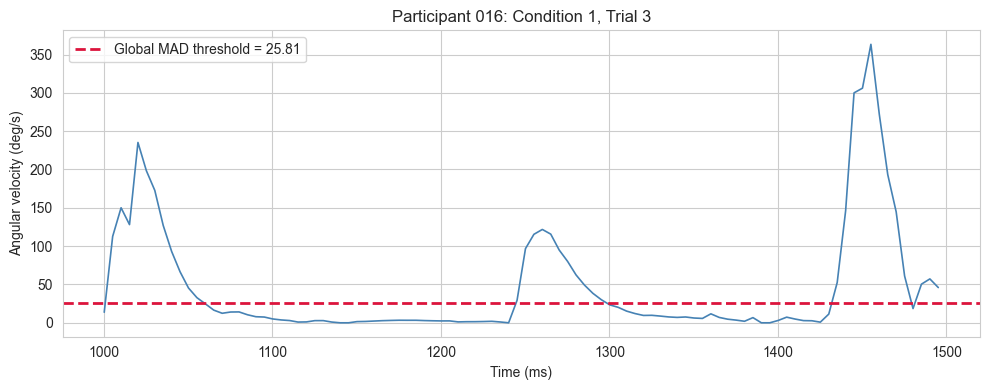

In [23]:
cond = 1
trial = 3

sub = df[
    (df["condition_number"] == cond) &
    (df["trial_number"] == trial) &
    (df["time_ms"]  > 1000) &
    (df["time_ms"]  < 1500)
].copy()

sub["angular_velocity"] = pd.to_numeric(sub["angular_velocity"], errors="coerce")
sub["time_ms"] = pd.to_numeric(sub["time_ms"], errors="coerce")

vel_all = pd.to_numeric(df["angular_velocity"], errors="coerce")
vel_all = vel_all[np.isfinite(vel_all)]

global_mad_threshold, global_trace = at_mad_threshold(vel_all, th_0=200.0)

plt.figure(figsize=(10, 4))
plt.plot(sub["time_ms"], sub["angular_velocity"], lw=1.2, color="steelblue")
plt.axhline(
    global_mad_threshold,
    color="crimson",
    ls="--",
    lw=2,
    label=f"Global MAD threshold = {global_mad_threshold:.2f}"
)
f"Participant {participant_id}: Condition {cond}, Trial {trial}"
plt.xlabel("Time (ms)")
plt.ylabel("Angular velocity (deg/s)")
plt.title(f"Participant {participant_id}: Condition {cond}, Trial {trial}")
plt.legend()
plt.tight_layout()
plt.show()

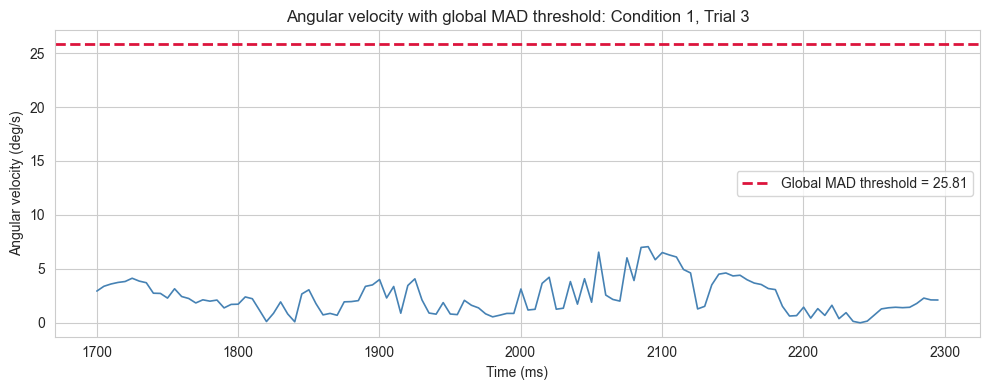

In [24]:
cond = 1
trial = 3

sub = df[
    (df["condition_number"] == cond) &
    (df["trial_number"] == trial) &
    (df["time_ms"]  > 1700) &
    (df["time_ms"]  < 2300)
].copy()

sub["angular_velocity"] = pd.to_numeric(sub["angular_velocity"], errors="coerce")
sub["time_ms"] = pd.to_numeric(sub["time_ms"], errors="coerce")

vel_all = pd.to_numeric(df["angular_velocity"], errors="coerce")
vel_all = vel_all[np.isfinite(vel_all)]

global_mad_threshold, global_trace = at_mad_threshold(vel_all, th_0=200.0)

plt.figure(figsize=(10, 4))
plt.plot(sub["time_ms"], sub["angular_velocity"], lw=1.2, color="steelblue")
plt.axhline(
    global_mad_threshold,
    color="crimson",
    ls="--",
    lw=2,
    label=f"Global MAD threshold = {global_mad_threshold:.2f}"
)

plt.xlabel("Time (ms)")
plt.ylabel("Angular velocity (deg/s)")
plt.title(f"Angular velocity with global MAD threshold: Condition {cond}, Trial {trial}")
plt.legend()
plt.tight_layout()
plt.show()

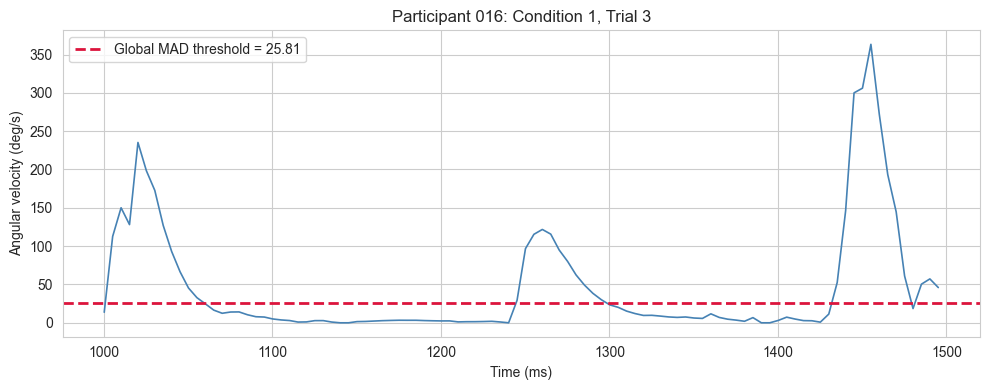

In [32]:
cond = 1
trial = 3

sub = df[
    (df["condition_number"] == cond) &
    (df["trial_number"] == trial) &
    (df["time_ms"] > 1000) &
    (df["time_ms"] < 1500)
].copy()

sub["angular_velocity"] = pd.to_numeric(sub["angular_velocity"], errors="coerce")
sub["time_ms"] = pd.to_numeric(sub["time_ms"], errors="coerce")

participant_id = sub["participant_id"].iloc[0]

vel_all = pd.to_numeric(df["angular_velocity"], errors="coerce")
vel_all = vel_all[np.isfinite(vel_all)]

global_mad_threshold, global_trace = at_mad_threshold(vel_all, th_0=200.0)

plt.figure(figsize=(10, 4))
plt.plot(sub["time_ms"], sub["angular_velocity"], lw=1.2, color="steelblue")
plt.axhline(
    global_mad_threshold,
    color="crimson",
    ls="--",
    lw=2,
    label=f"Global MAD threshold = {global_mad_threshold:.2f}"
)

plt.xlabel("Time (ms)")
plt.ylabel("Angular velocity (deg/s)")
plt.title(
    f"Participant {participant_id}: Condition {cond}, Trial {trial}"
)
plt.legend()
plt.tight_layout()
plt.show()


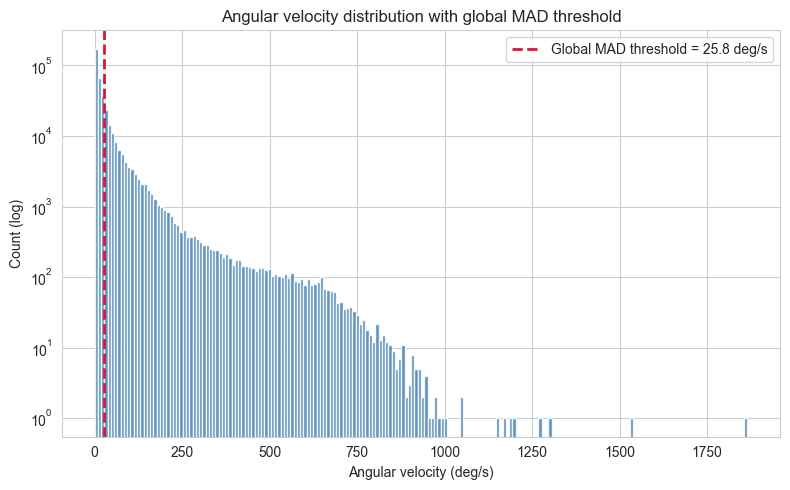

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

vel = pd.to_numeric(df["angular_velocity"], errors="coerce")
vel = vel[np.isfinite(vel)]

global_mad_threshold, global_trace = at_mad_threshold(vel, th_0=200.0)

plt.figure(figsize=(8, 5))
plt.hist(vel, bins=200, color="steelblue", alpha=0.85)
plt.yscale("log")

plt.axvline(
    global_mad_threshold,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Global MAD threshold = {global_mad_threshold:.1f} deg/s"
)

plt.xlabel("Angular velocity (deg/s)")
plt.ylabel("Count (log)")
plt.title("Angular velocity distribution with global MAD threshold")
plt.legend()
plt.tight_layout()
plt.show()


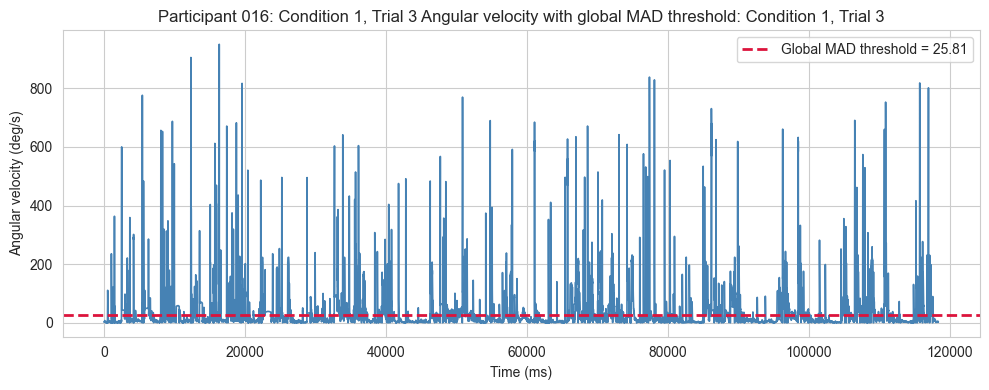

In [31]:
cond = 1
trial = 3

sub = df[
    (df["condition_number"] == cond) &
    (df["trial_number"] == trial)
].copy()

sub["angular_velocity"] = pd.to_numeric(sub["angular_velocity"], errors="coerce")
sub["time_ms"] = pd.to_numeric(sub["time_ms"], errors="coerce")

vel_all = pd.to_numeric(df["angular_velocity"], errors="coerce")
vel_all = vel_all[np.isfinite(vel_all)]

global_mad_threshold, global_trace = at_mad_threshold(vel_all, th_0=200.0)

plt.figure(figsize=(10, 4))
plt.plot(sub["time_ms"], sub["angular_velocity"], lw=1.2, color="steelblue")
plt.axhline(
    global_mad_threshold,
    color="crimson",
    ls="--",
    lw=2,
    label=f"Global MAD threshold = {global_mad_threshold:.2f}"
)

plt.xlabel("Time (ms)")
plt.ylabel("Angular velocity (deg/s)")
plt.title(f"Angular velocity with global MAD threshold: Condition {cond}, Trial {trial}")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,trial_number,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id
0,1000001481958514100,1778060264384,592.3813,2.000000,232023,0.000000,Valid,-0.097741,0.230809,0.968077,...,0,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001
1,1000001481963514900,1778060264384,592.3813,2.000000,232024,0.000000,Valid,-0.097410,0.230441,0.968198,...,0,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001
2,1000001481968515700,1778060264384,592.3813,2.000000,232025,0.000000,Valid,-0.097012,0.229992,0.968345,...,0,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001
3,1000001481973516500,1778060264384,592.3813,2.000000,232026,0.000000,Valid,-0.096599,0.229737,0.968447,...,0,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001
4,1000001481978516800,1778060264384,592.3813,2.000000,232027,0.000000,Valid,-0.096269,0.230169,0.968377,...,0,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553473,1000005111509028100,1778063893701,3746.4670,1.157945,957652,0.027887,Valid,0.076445,0.145445,0.986409,...,6,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001
553474,1000005111514028600,1778063893701,3746.4670,1.148934,957653,0.000000,Valid,0.075853,0.145398,0.986461,...,6,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001
553475,1000005111519029800,1778063893711,3746.4780,1.150903,957654,0.000000,Valid,0.075171,0.145675,0.986472,...,6,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001
553476,1000005111524031000,1778063893711,3746.4780,1.141437,957655,0.000000,Valid,0.074669,0.146021,0.986460,...,6,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001


In [9]:
df["trial_number"].value_counts()

trial_number
2    106543
4    102036
1     82245
3     71251
6     67567
5     66770
0     57066
Name: count, dtype: int64

In [10]:
df["condition_number"].value_counts()

condition_number
2    211218
3    184443
1    157817
Name: count, dtype: int64

In [11]:
df["participant_id"].value_counts()

participant_id
001    553478
Name: count, dtype: int64

In [63]:
def add_saccade_fixation_ids(
    df,
    group_cols=("condition_number", "trial_number"),
    category_col="velocity_category",
    time_col="time_ms",
):
    """
    Add separate IDs for consecutive saccade and fixation runs.

    Output columns:
    - saccade_id
    - fixation_id
    - event_duration_ms

    Duration is computed as:
    number_of_rows_in_event * median_dt_within_trial
    """
    out = df.copy()
    out = out.sort_values(list(group_cols) + [time_col]).copy()

    out["saccade_id"] = pd.Series(index=out.index, dtype="Int64")
    out["fixation_id"] = pd.Series(index=out.index, dtype="Int64")
    out["event_duration_ms"] = np.nan

    saccade_counter = 0
    fixation_counter = 0

    for _, sub in out.groupby(list(group_cols), sort=False):
        sub = sub.sort_values(time_col)

        labels = sub[category_col].tolist()
        times = pd.to_numeric(sub[time_col], errors="coerce").to_numpy()
        idx = sub.index.to_list()

        # Estimate sampling interval for this trial
        dt = np.diff(times)
        dt = dt[np.isfinite(dt) & (dt > 0)]
        median_dt = float(np.median(dt)) if len(dt) > 0 else np.nan

        run_start = 0

        for i in range(1, len(sub) + 1):
            if i == len(sub):
                run_ended = True
            else:
                curr_label = labels[i]
                start_label = labels[run_start]

                if pd.isna(curr_label) and pd.isna(start_label):
                    run_ended = False
                elif pd.isna(curr_label) or pd.isna(start_label):
                    run_ended = True
                else:
                    run_ended = curr_label != start_label

            if not run_ended:
                continue

            label = labels[run_start]
            run_idx = idx[run_start:i]
            n_rows = len(run_idx)

            if pd.notna(label) and n_rows > 0 and np.isfinite(median_dt):
                duration_ms = n_rows * median_dt
                out.loc[run_idx, "event_duration_ms"] = duration_ms

                if label == "saccade":
                    saccade_counter += 1
                    out.loc[run_idx, "saccade_id"] = saccade_counter

                elif label == "fixation":
                    fixation_counter += 1
                    out.loc[run_idx, "fixation_id"] = fixation_counter

            run_start = i

    return out


In [64]:
df = add_saccade_fixation_ids(df)

In [57]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,mad_threshold,velocity_category,saccade_id,fixation_id,event_duration_ms
0,1000002319866583700,1778654030248,450.4382,0.597287,450888,1.0,Valid,0.118195,-0.302303,0.945856,...,0.118145,-0.302262,0.945875,C1_T0,NaN,35.720911,<NA>,<NA>,<NA>,NaN
1,1000002319871582900,1778654030249,450.4382,0.597693,450889,1.0,Valid,0.118145,-0.302262,0.945875,...,0.118121,-0.302237,0.945886,C1_T0,0.417694,35.720911,fixation,<NA>,1,20.0024
2,1000002319876583600,1778654030249,450.4382,0.598473,450890,1.0,Valid,0.118097,-0.302212,0.945897,...,0.118097,-0.302212,0.945897,C1_T0,0.417569,35.720911,fixation,<NA>,1,20.0024
3,1000002319881583700,1778654030249,450.4382,0.599141,450891,1.0,Valid,0.118019,-0.302093,0.945944,...,0.118102,-0.302104,0.945931,C1_T0,1.296620,35.720911,fixation,<NA>,1,20.0024
4,1000002319886580400,1778654030249,450.4382,0.599495,450892,1.0,Valid,0.117848,-0.301896,0.946029,...,0.118109,-0.301925,0.945987,C1_T0,2.152507,35.720911,fixation,<NA>,1,20.0024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488144,1000006587138991300,1778658297312,3475.0390,1.067794,1304015,0.0,Valid,-0.097420,0.349325,0.931923,...,-0.097420,0.349325,0.931923,C3_T6,178.243889,35.720911,saccade,20348,<NA>,55.0066
488145,1000006587143992500,1778658297312,3475.0390,0.997467,1304016,0.0,Valid,-0.103255,0.359735,0.927323,...,-0.103255,0.359735,0.927323,C3_T6,146.523796,35.720911,saccade,20348,<NA>,55.0066
488146,1000006587148992700,1778658297323,3475.0500,0.961966,1304017,0.0,Valid,-0.109458,0.366663,0.923893,...,-0.109479,0.362374,0.925580,C3_T6,79.996268,35.720911,saccade,20348,<NA>,55.0066
488147,1000006587153993900,1778658297323,3475.0500,0.949634,1304018,0.0,Valid,-0.110973,0.365730,0.924081,...,-0.110226,0.364053,0.924833,C3_T6,22.726699,35.720911,fixation,<NA>,20366,10.0012


In [52]:
df.head()

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,mad_threshold,velocity_category,saccade_id,fixation_id,event_duration_ms
0,1000100376904928200,1778826383977,591.5391,1.023939,64073,0.789749,Valid,-0.232266,-0.191211,0.953673,...,-0.231575,-0.191438,0.953795,C1_T0,NaN,25.809083,<NA>,<NA>,<NA>,NaN
1,1000100376909927100,1778826383977,591.5391,1.005479,64074,0.784619,Valid,-0.231575,-0.191438,0.953795,...,-0.231171,-0.191596,0.953861,C1_T0,5.032963,25.809083,fixation,<NA>,1,80.0096
2,1000100376914927900,1778826383977,591.5391,0.984855,64075,0.788606,Valid,-0.230766,-0.191753,0.953928,...,-0.230766,-0.191753,0.953928,C1_T0,5.031051,25.809083,fixation,<NA>,1,80.0096
3,1000100376919928700,1778826383977,591.5391,0.963226,64076,0.777880,Valid,-0.229765,-0.191962,0.954127,...,-0.229765,-0.191961,0.954127,C1_T0,11.940895,25.809083,fixation,<NA>,1,80.0096
4,1000100376924937100,1778826383977,591.5391,0.944364,64077,0.773483,Valid,-0.228605,-0.192091,0.954380,...,-0.228611,-0.191966,0.954404,C1_T0,13.576025,25.809083,fixation,<NA>,1,80.0096


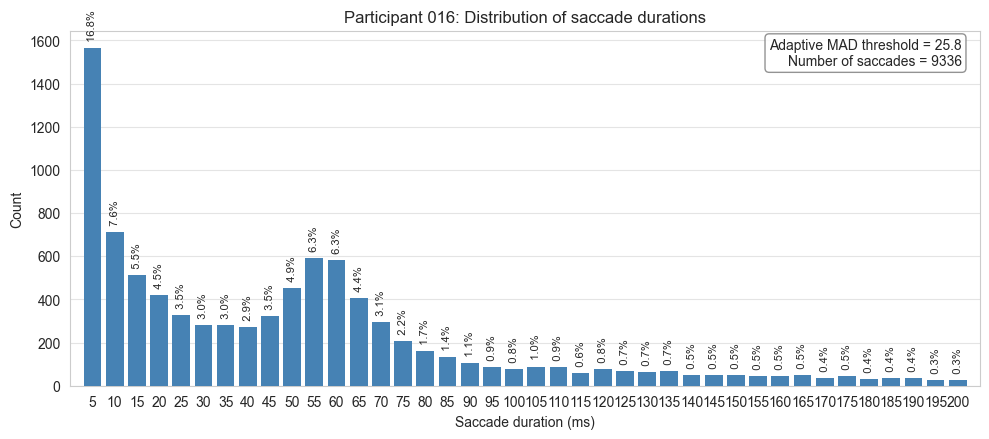

In [94]:
import pandas as pd
import matplotlib.pyplot as plt

# One row per saccade event
saccade_events = (
    df.dropna(subset=["saccade_id"])
      .groupby("saccade_id", as_index=False)
      .agg(duration_ms=("event_duration_ms", "first"))
)

# Keep only durations from 5 to 200 ms
saccade_events_plot = saccade_events[
    (saccade_events["duration_ms"] >= 5) &
    (saccade_events["duration_ms"] <= 205)
].copy()

# Round durations to nearest 5 ms
saccade_events_plot["duration_bin"] = (
    5 * (saccade_events_plot["duration_ms"] / 5).round()
).astype(int)

# Count saccades per 5 ms bin
duration_counts = (
    saccade_events_plot["duration_bin"]
    .value_counts()
    .sort_index()
)

# Total number of all saccade events
total_saccades = saccade_events["saccade_id"].nunique()

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.bar(
    duration_counts.index,
    duration_counts.values,
    width=4.0,
    color="steelblue",
    linewidth=0,
    zorder=3
)

# One percentage above each bar
for x, count in zip(duration_counts.index, duration_counts.values):
    pct = 100 * count / total_saccades
    ax.text(
        x,
        count + 3,
        f"  {pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90
    )
info_text = (
    f"Adaptive MAD threshold = {global_mad_threshold:.1f}\n"
    f"Number of saccades = {total_saccades}"
)
ax.text(
    0.98, 0.98,
    info_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="gray")
)

ax.set_axisbelow(True)
ax.grid(axis="y", color="lightgray", alpha=0.6, zorder=0)
ax.grid(axis="x", visible=False)

ax.set_xlabel("Saccade duration (ms)")
ax.set_ylabel("Count")
ax.set_title(f"Participant {participant_id}: Distribution of saccade durations")

ax.set_xticks(range(5, 205, 5))
ax.set_xlim(0, 205)

plt.tight_layout()
plt.show()


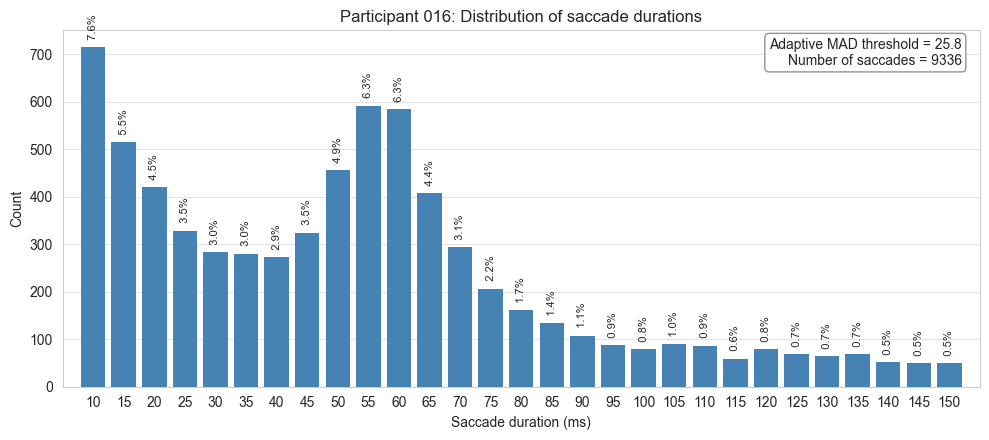

In [103]:
import pandas as pd
import matplotlib.pyplot as plt

# One row per saccade event
saccade_events = (
    df.dropna(subset=["saccade_id"])
      .groupby("saccade_id", as_index=False)
      .agg(duration_ms=("event_duration_ms", "first"))
)

# Keep only durations from 5 to 200 ms
saccade_events_plot = saccade_events[
    (saccade_events["duration_ms"] >= 10) &
    (saccade_events["duration_ms"] <= 155)
].copy()

# Round durations to nearest 5 ms
saccade_events_plot["duration_bin"] = (
    5 * (saccade_events_plot["duration_ms"] / 5).round()
).astype(int)

# Count saccades per 5 ms bin
duration_counts = (
    saccade_events_plot["duration_bin"]
    .value_counts()
    .sort_index()
)

# Total number of all saccade events
total_saccades = saccade_events["saccade_id"].nunique()

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.bar(
    duration_counts.index,
    duration_counts.values,
    width=4.0,
    color="steelblue",
    linewidth=0,
    zorder=3
)

# One percentage above each bar
for x, count in zip(duration_counts.index, duration_counts.values):
    pct = 100 * count / total_saccades
    ax.text(
        x,
        count + 3,
        f"  {pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90
    )
info_text = (
    f"Adaptive MAD threshold = {global_mad_threshold:.1f}\n"
    f"Number of saccades = {total_saccades}"
)
ax.text(
    0.98, 0.98,
    info_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="gray")
)
ax.set_axisbelow(True)
ax.grid(axis="y", color="lightgray", alpha=0.6, zorder=0)
ax.grid(axis="x", visible=False)

ax.set_xlabel("Saccade duration (ms)")
ax.set_ylabel("Count")
ax.set_title(f"Participant {participant_id}: Distribution of saccade durations")

ax.set_xticks(range(10, 155, 5))
ax.set_xlim(5, 155)

plt.tight_layout()
plt.show()


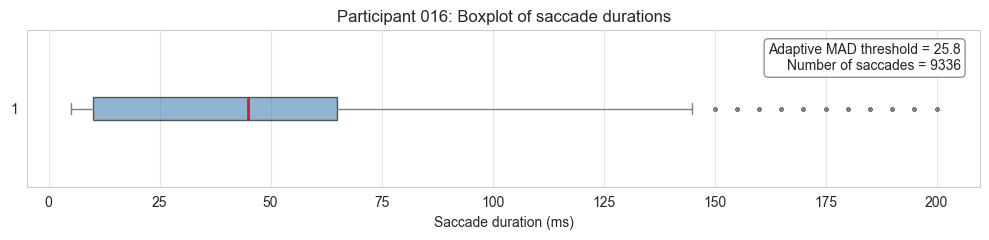

In [95]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 2.5))

ax.boxplot(
    saccade_events_plot["duration_ms"].dropna(),
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6),
    medianprops=dict(color="crimson", linewidth=2),
    whiskerprops=dict(color="gray"),
    capprops=dict(color="gray"),
    flierprops=dict(marker="o", markerfacecolor="gray", markersize=3, alpha=0.4, markeredgecolor="none")
)

info_text = (
    f"Adaptive MAD threshold = {global_mad_threshold:.1f}\n"
    f"Number of saccades = {total_saccades}"
)

ax.text(
    0.98, 0.92,
    info_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="gray")
)

ax.set_xlabel("Saccade duration (ms)")
ax.set_title(f"Participant {participant_id}: Boxplot of saccade durations")
ax.grid(axis="x", color="lightgray", alpha=0.6)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()


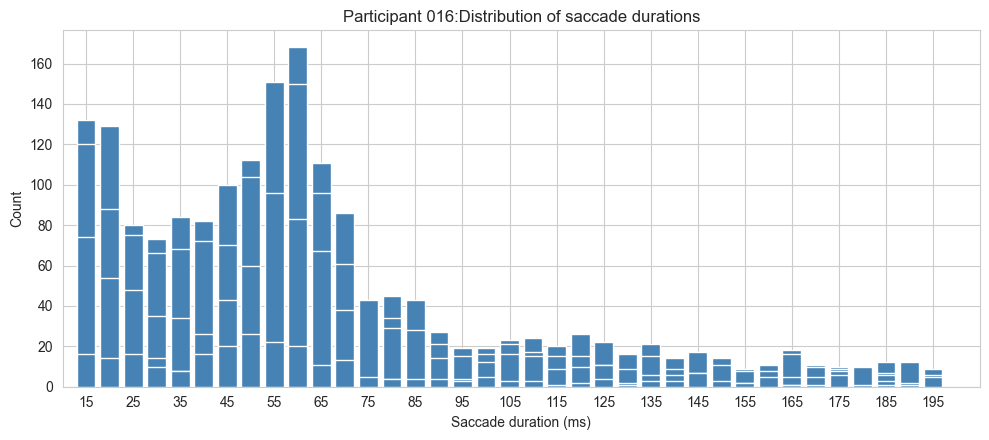

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# One row per saccade event
saccade_events = (
    df.dropna(subset=["saccade_id"])
      .groupby("saccade_id", as_index=False)
      .agg(duration_ms=("event_duration_ms", "first"))
)

# Optional: focus on the main range
saccade_events_plot = saccade_events[
    (saccade_events["duration_ms"] >= 15) &
    (saccade_events["duration_ms"] <= 200)
].copy()

# Count exact duration values (5, 10, 15, ...)
duration_counts = (
    saccade_events_plot["duration_ms"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 4.5))
plt.bar(
    duration_counts.index,
    duration_counts.values,
    width=4.0,
    color="steelblue"
)

plt.xlabel("Saccade duration (ms)")
plt.ylabel("Count")
plt.title(f"Participant {participant_id}:Distribution of saccade durations")
plt.xticks(range(15, 205, 10))
plt.xlim(10, 205)
plt.tight_layout()
plt.show()


In [93]:
# Basic summary
n_saccades = len(saccade_events)
max_duration = saccade_events["duration_ms"].max()
mean_duration = saccade_events["duration_ms"].mean()
median_duration = saccade_events["duration_ms"].median()


print("Number of saccades:", n_saccades)
print("Maximum saccade duration (ms):", max_duration)
print("Mean of saccade duration (ms):", mean_duration)
print("Median duration (ms):", median_duration)


Number of saccades: 9336
Maximum saccade duration (ms): 1035.1241999998747
Mean of saccade duration (ms): 61.65372023347995
Median duration (ms): 45.006299999971816


In [100]:
print(f"Participant:{participant_id}")
print(saccade_events["duration_ms"].describe())

Participant:016
count    9336.000000
mean       61.653720
std        71.191263
min         5.000600
25%        15.001800
50%        45.006300
75%        70.009800
max      1035.124200
Name: duration_ms, dtype: float64


In [68]:
largest_saccades = saccade_events.sort_values("duration_ms", ascending=False).head(10)
largest_saccades

,saccade_id,duration_ms
1848,1849,965.1351
2348,2349,600.0840
7573,7574,595.0714
14925,14926,590.0708
536,537,570.0798
17151,17152,570.0684
16932,16933,545.0654
1042,1043,525.0735
3441,3442,510.0714
17590,17591,500.0600


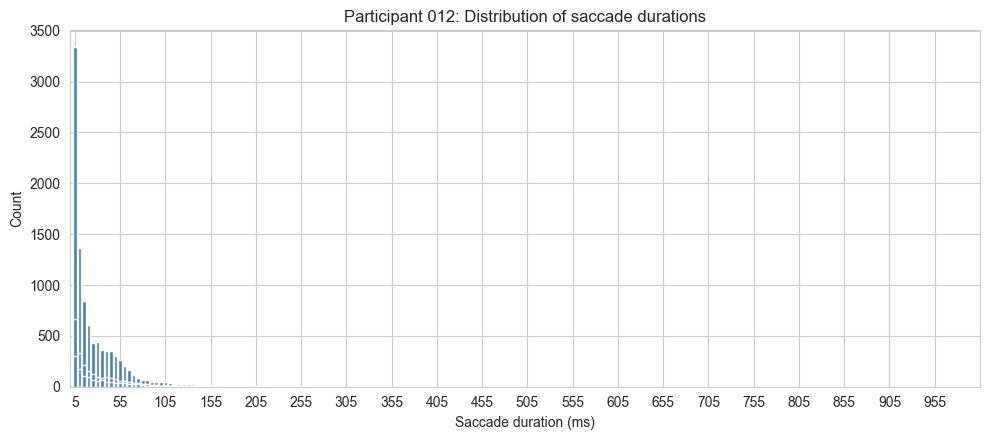

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# One row per saccade event
saccade_events = (
    df.dropna(subset=["saccade_id"])
      .groupby("saccade_id", as_index=False)
      .agg(duration_ms=("event_duration_ms", "first"))
)

# Optional: focus on the main range
saccade_events_plot = saccade_events[
    saccade_events["duration_ms"] <= 1000
].copy()

# Count exact duration values (5, 10, 15, ...)
duration_counts = (
    saccade_events_plot["duration_ms"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 4.5))
plt.bar(
    duration_counts.index,
    duration_counts.values,
    width=4.0,
    color="steelblue"
)

plt.xlabel("Saccade duration (ms)")
plt.ylabel("Count")
plt.title(f"Participant {participant_id}: Distribution of saccade durations")
plt.xticks(range(5, 1005, 50))
plt.xlim(0, 1005)
plt.tight_layout()
plt.show()


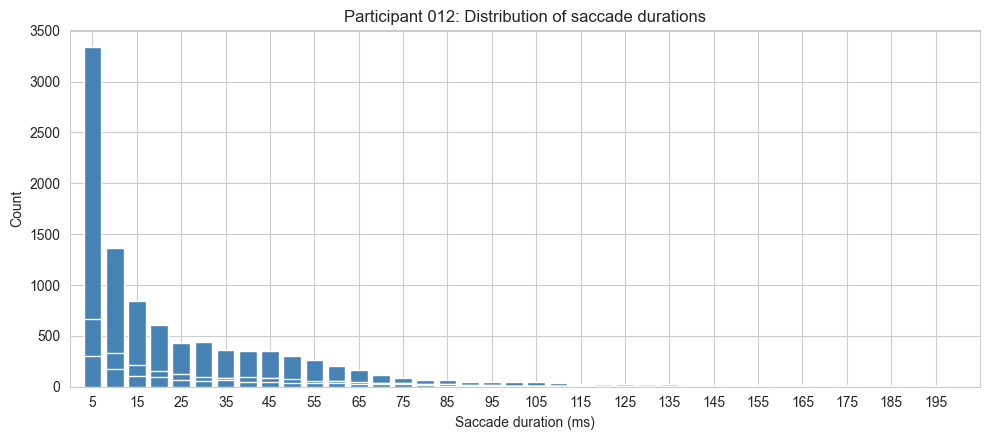

In [214]:
plt.figure(figsize=(10, 4.5))

plt.bar(
    duration_counts.index,
    duration_counts.values,
    width=4.0,
    color="steelblue",
    zorder=3
)

plt.grid(axis="y", zorder=0)

plt.xlabel("Saccade duration (ms)")
plt.ylabel("Count")
plt.title(f"Participant {participant_id}: Distribution of saccade durations")
plt.xticks(range(5, 205, 10))
plt.xlim(0, 205)
plt.tight_layout()
plt.show()


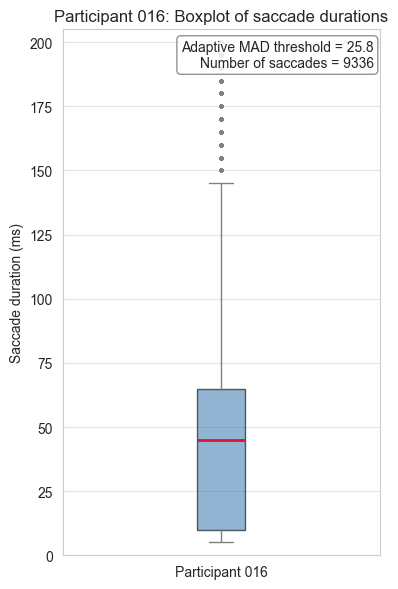

In [96]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 6))

ax.boxplot(
    saccade_events_plot["duration_ms"].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6),
    medianprops=dict(color="crimson", linewidth=2),
    whiskerprops=dict(color="gray"),
    capprops=dict(color="gray"),
    flierprops=dict(
        marker="o",
        markerfacecolor="gray",
        markersize=3,
        alpha=0.4,
        markeredgecolor="none"
    )
)

info_text = (
    f"Adaptive MAD threshold = {global_mad_threshold:.1f}\n"
    f"Number of saccades = {total_saccades}"
)

ax.text(
    0.98, 0.98,
    info_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="gray")
)

ax.set_ylabel("Saccade duration (ms)")
ax.set_title(f"Participant {participant_id}: Boxplot of saccade durations")
ax.set_xticks([1])
ax.set_xticklabels([f"Participant {participant_id}"])
ax.set_ylim(0, 205)

ax.grid(axis="y", color="lightgray", alpha=0.6)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()


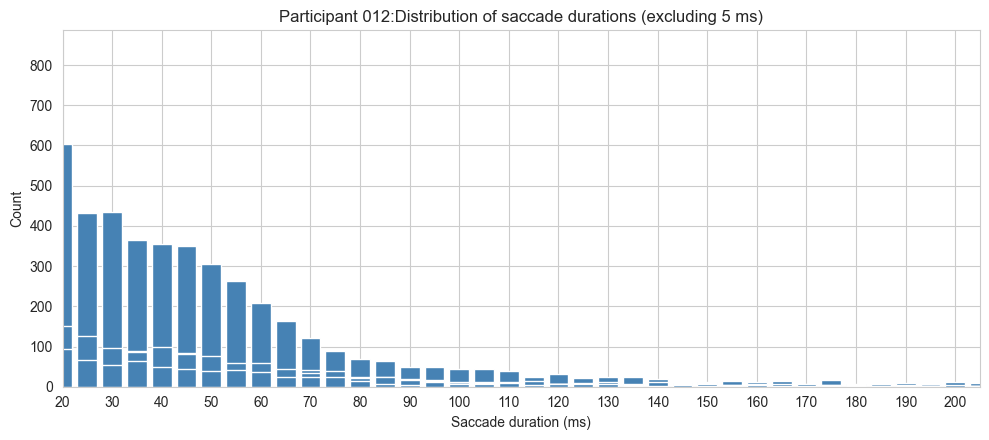

In [216]:
saccade_events_plot = saccade_events[saccade_events["duration_ms"] > 11].copy()

duration_counts = (
    saccade_events_plot["duration_ms"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 4.5))
plt.bar(
    duration_counts.index,
    duration_counts.values,
    width=4.0,
    color="steelblue",
    edgecolor="white"
)

plt.xlabel("Saccade duration (ms)")
plt.ylabel("Count")
plt.title(f"Participant {participant_id}:Distribution of saccade durations (excluding 5 ms)")
plt.xticks(range(20, 205, 10))
plt.xlim(20, 205)
plt.tight_layout()
plt.show()


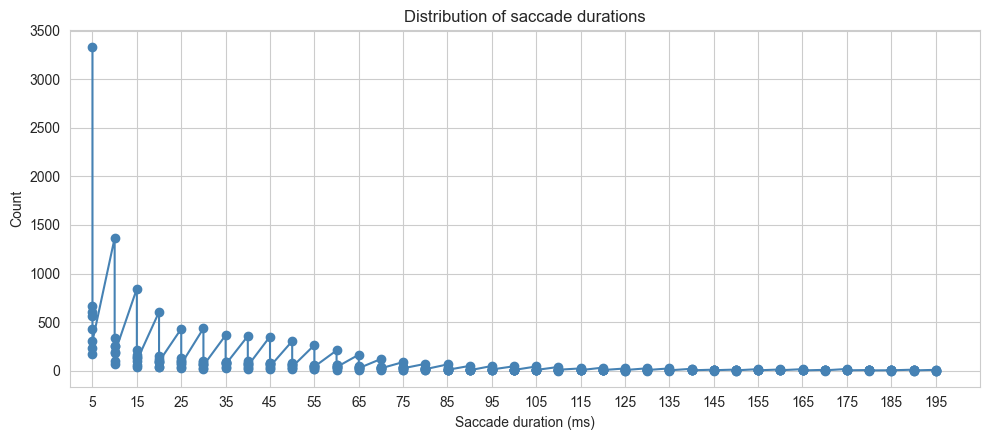

In [191]:
plt.figure(figsize=(10, 4.5))
plt.plot(duration_counts.index, duration_counts.values, marker="o", color="steelblue")
plt.xlabel("Saccade duration (ms)")
plt.ylabel("Count")
plt.title("Distribution of saccade durations")
plt.xticks(range(5, 205, 10))
plt.xlim(0, 205)
plt.tight_layout()
plt.show()


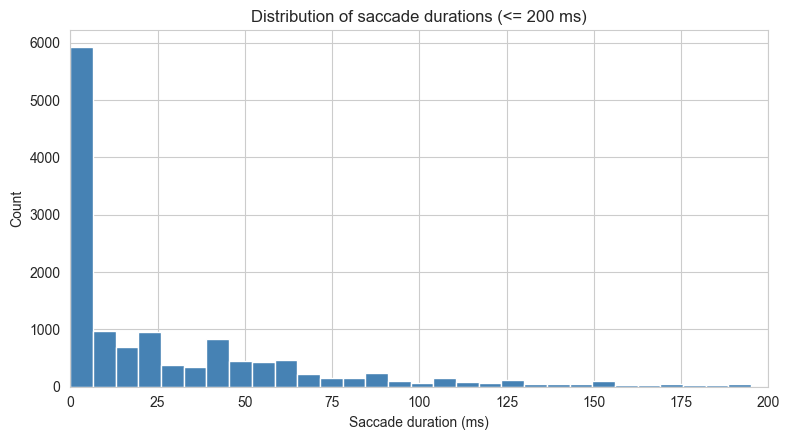

In [143]:
import matplotlib.pyplot as plt

# Keep only saccades up to 200 ms for plotting
saccade_events_200 = saccade_events[saccade_events["duration_ms"] <= 200].copy()

plt.figure(figsize=(8, 4.5))
plt.hist(
    saccade_events_200["duration_ms"].dropna(),
    bins=30,
    color="steelblue",
    edgecolor="white"
)

plt.xlabel("Saccade duration (ms)")
plt.ylabel("Count")
plt.title("Distribution of saccade durations (<= 200 ms)")
plt.xlim(0, 200)
plt.tight_layout()
plt.show()


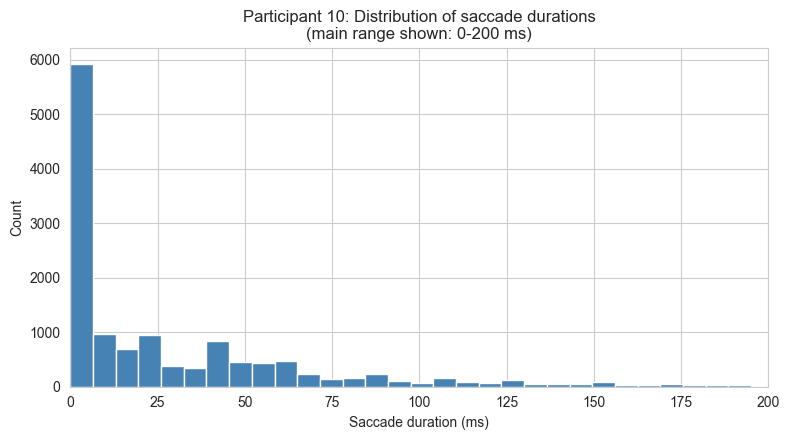

In [150]:
plt.figure(figsize=(8, 4.5))
plt.hist(
    saccade_events_200["duration_ms"].dropna(),
    bins=30,
    color="steelblue",
    edgecolor="white"
)

plt.xlabel("Saccade duration (ms)")
plt.ylabel("Count")
plt.title("Distribution of saccade durations\n(main range shown: 0-200 ms)")
plt.xlim(0, 200)
plt.tight_layout()
plt.show()


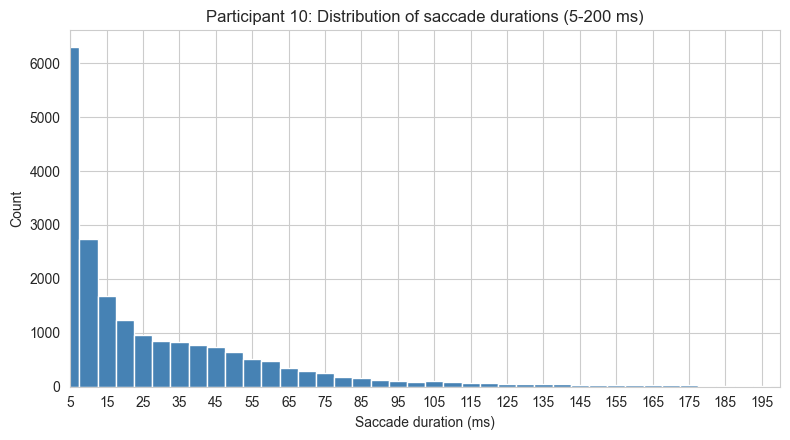

In [188]:
import numpy as np
import matplotlib.pyplot as plt

# Keep only durations from 5 to 200 ms
saccade_events_plot = saccade_events[
    (saccade_events["duration_ms"] >= 5) &
    (saccade_events["duration_ms"] <= 200)
].copy()

# 5 ms bins: 5, 10, 15, ..., 200
bins = np.arange(5, 205, 5)

plt.figure(figsize=(8, 4.5))
plt.hist(
    saccade_events_plot["duration_ms"].dropna(),
    bins=bins,
    color="steelblue",
    edgecolor="white",
    align="left"
)

plt.xlabel("Saccade duration (ms)")
plt.ylabel("Count")
plt.title("Participant 10: Distribution of saccade durations (5-200 ms)")
plt.xlim(5, 200)
plt.xticks(np.arange(5, 205, 10))
plt.tight_layout()
plt.show()
